# Tutorial 15: Reaction Wheel & Magnetorquer Slew Control

This tutorial covers Attitude Control strategies for spacecraft detumbling and precise attitude slewing using **B-Dot controllers** for Magnetorquers and **PID controllers** for Reaction Wheels.

---

## 1. Theory Prerequisite

### 1.1 B-Dot Detumbling
When a spacecraft is tumbling tipsy after release, Magnetorquers (MGT) can interact with the Earth's magnetic field $B$ to generate damping torque.

- **Control Law**: Dipole Moment $m = -K \dot{B}$
- **Torque Produced**: $T = m \times B$
- **Effect**: Slows down the rotation rate without requiring reaction wheels.

### 1.2 PID Slew Control
Once detumbled, precise re-orientation requires Reaction Wheels (RW).

- **Input**: Angular error (e.g., from quaternions)
- **Action**: Controller $u = K_p e + K_i \int e dt + K_d \dot{e}$
- **Output**: Desired momentum exchange causing rotational acceleration opposite to rigid body.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from gnc_toolkit.classical_control.bdot import BDot
from gnc_toolkit.classical_control.pid import PID

print("Imports successful.")

Imports successful.


## 2. Demonstration: B-Dot Detumbling Simulation

We simulate a tumbling spacecraft slowing down its angular rates via magnetic torque interaction.

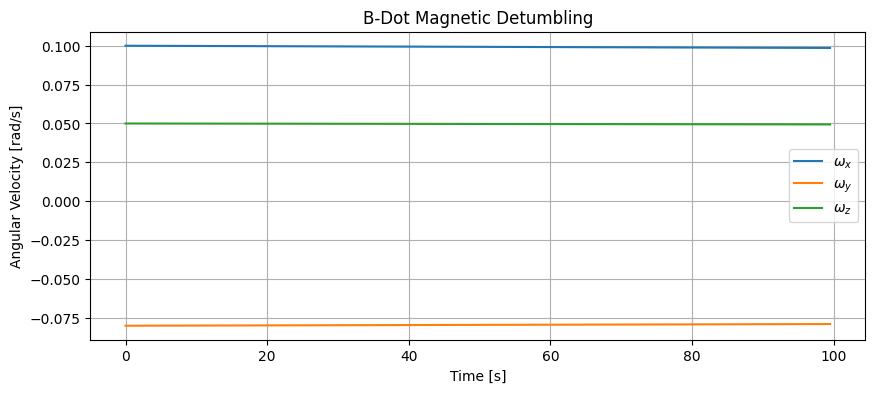

Final rates magnitude: 0.13557 rad/s


In [2]:
# Spacecraft Properties
Inertia = np.diag([0.1, 0.1, 0.1])  # 3U CubeSat kind [kg*m^2]
inv_I = np.linalg.inv(Inertia)

omega = np.array([0.1, -0.08, 0.05])  # Initial tumbling rates [rad/s]
B_field = np.array([2e-5, 1e-5, -3e-5])  # Earth B-field approximation [Tesla]

bdot_ctrl = BDot(gain=10000.0)  # High gain for demo scaling

dt = 0.5
steps = 200
history_omega = []

for k in range(steps):
    # 1. Measure B_dot (approximated here via cross product w x B for body rotation info)
    # B_dot in body frame: dB_dt = - omega x B
    B_dot = -np.cross(omega, B_field)
    
    # 2. Control Output
    dipole = bdot_ctrl.calculate_control(B_dot)
    
    # 3. Torque generation
    T_ctrl = np.cross(dipole, B_field)
    
    # 4. Dynamics (Euler's equations):
    # I * omega_dot + omega x (I * omega) = T
    omega_dot = inv_I @ (T_ctrl - np.cross(omega, Inertia @ omega))
    omega = omega + omega_dot * dt
    
    history_omega.append(omega.copy())
    
history_omega = np.array(history_omega)
time = np.arange(steps) * dt

plt.figure(figsize=(10, 4))
plt.plot(time, history_omega[:, 0], label='$\omega_x$')
plt.plot(time, history_omega[:, 1], label='$\omega_y$')
plt.plot(time, history_omega[:, 2], label='$\omega_z$')
plt.xlabel('Time [s]')
plt.ylabel('Angular Velocity [rad/s]')
plt.title('B-Dot Magnetic Detumbling')
plt.legend()
plt.grid(True)
plt.show()

print(f"Final rates magnitude: {np.linalg.norm(omega):.5f} rad/s")

## 3. Demonstration: PID Slew Maneuver

Here we control a single axis angle using a Reaction Wheel output mapping into PID demands.

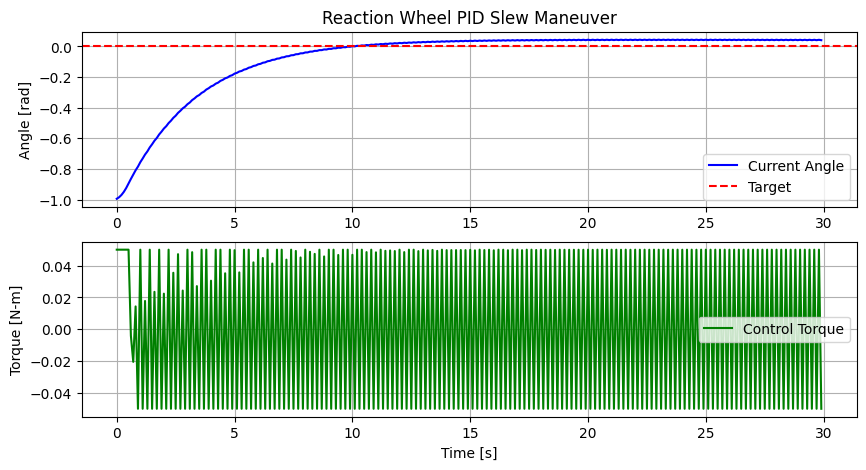

In [3]:
# 1D Angle Tracking loop
pid_axis = PID(kp=1.0, ki=0.01, kd=3.0, output_limits=(-0.05, 0.05))  # Torque limits [Nm]

angle = -1.0  # radians (Start demand from -1 rad offset index offset)
rate = 0.0
target_angle = 0.0

dt_pid = 0.1
slew_steps = 300
history_angle = []
history_torque = []
I_axis = 0.1

for k in range(slew_steps):
    error = target_angle - angle
    
    # Update PID
    torque = pid_axis.update(error, dt_pid)
    
    # 1D Rigid Dynamics
    accel = torque / I_axis
    rate += accel * dt_pid
    angle += rate * dt_pid
    
    history_angle.append(angle)
    history_torque.append(torque)
    
time_slew = np.arange(slew_steps) * dt_pid

plt.figure(figsize=(10, 5))
plt.subplot(2, 1, 1)
plt.plot(time_slew, history_angle, 'b-', label='Current Angle')
plt.axhline(y=target_angle, color='r', linestyle='--', label='Target')
plt.ylabel('Angle [rad]')
plt.title('Reaction Wheel PID Slew Maneuver')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(time_slew, history_torque, 'g-', label='Control Torque')
plt.ylabel('Torque [N-m]')
plt.xlabel('Time [s]')
plt.legend()
plt.grid(True)
plt.show()